In [ ]:
#P1

#Code by Parthiv Abhani (1106)
!pip install tensorflow

import tensorflow as tf
from tensorflow import keras
import numpy as np

# Check TensorFlow version
print("TensorFlow Version:", tf.__version__)

# Create a Tensor
tensor = tf.constant([[1, 2], [3, 4]])
print("\nTensor:")
print(tensor)

# Build a Simple Neural Network
model = keras.Sequential([
    keras.layers.Input(shape=(4,)),
    keras.layers.Dense(8, activation="relu"),
    keras.layers.Dense(3, activation="softmax")
])

# Compile the Model
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# Display Model Summary
model.summary()

# Create Dummy Data
X = np.random.rand(100, 4)
y = np.random.randint(0, 3, 100)

# Train the Model
model.fit(X, y, epochs=5, batch_size=16)

# Make Predictions
predictions = model.predict(X[:5])

print("\nPredictions:")
print(predictions)
print("\nPredicted Classes:")
print(np.argmax(predictions, axis=1))

TensorFlow Version: 2.20.0

Tensor:
tf.Tensor(
[[1 2]
 [3 4]], shape=(2, 2), dtype=int32)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 8)              │            40 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │            27 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 67 (268.00 B)

 Trainable params: 67 (268.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.3600 - loss: 1.4466
Epoch 2/5
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.3600 - loss: 1.3984  
Epoch 3/5
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.3600 - loss: 1.3549 
Epoch 4/5
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.3600 - loss: 1.3169 
Epoch 5/5
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.3600 - loss: 1.2806
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step

Predictions:
[[0.6279027  0.07315026 0.298947  ]
 [0.6576878  0.15794875 0.18436348]
 [0.6251768  0.08512238 0.28970093]
 [0.60400176 0.14899674 0.24700156]
 [0.6768009  0.17584433 0.14735483]]

Predicted Classes:
[0 0 0 0 0]


In [ ]:
# P2
# Housing Price Prediction using Deep Feed Forward Neural Network
# Code by Parthiv Abhani

import numpy as np
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# Load Housing Dataset
data = fetch_california_housing()
X = data.data
y = data.target

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Normalize data
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Deep Feed Forward Neural Network
model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(32, activation='relu'),
    Dense(1)
])

# Compile model
model.compile(optimizer='adam', loss='mse', metrics=['mae'])

# Train model
model.fit(X_train, y_train, epochs=10, batch_size=32, verbose=1)

# Predict
y_pred = model.predict(X_test)

# Evaluate
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print("MAE :", round(mae, 3))
print("MSE :", round(mse, 3))
print("RMSE:", round(rmse, 3))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
516/516 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.8090 - mae: 0.6143
Epoch 2/10
516/516 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.4109 - mae: 0.4503
Epoch 3/10
516/516 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3754 - mae: 0.4332
Epoch 4/10
516/516 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3573 - mae: 0.4205
Epoch 5/10
516/516 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3353 - mae: 0.4063
Epoch 6/10
516/516 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3488 - mae: 0.4021
Epoch 7/10
516/516 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3225 - mae: 0.3949
Epoch 8/10
516/516 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3122 - mae: 0.3896
Epoch 9/10
516/516 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3098 - mae: 0.3850
Epoch 10/10
516/516 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3001 - mae: 0.3822
129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
MAE : 0.383
MSE : 0.313
RMSE: 0.559


In [ ]:
# P3

# Classification using Deep Feed Forward Neural Network

# Code by Parthiv Abhani

import numpy as np
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# Load dataset
data = load_breast_cancer()
X = data.data
y = data.target

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Normalize data
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Deep Feed Forward Neural Network
model = Sequential([
    Dense(32, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')
])

# Compile model
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

# Train model
model.fit(X_train, y_train, epochs=10, batch_size=32, verbose=1)

# Predict
y_pred = (model.predict(X_test) > 0.5).astype(int)

# Evaluate
accuracy = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

print("Accuracy:", round(accuracy * 100, 2), "%")
print("\nConfusion Matrix:")
print(cm)

Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5385 - loss: 0.7026
Epoch 2/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8418 - loss: 0.4814 
Epoch 3/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9187 - loss: 0.3475 
Epoch 4/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9341 - loss: 0.2596 
Epoch 5/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9495 - loss: 0.2041 
Epoch 6/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9516 - loss: 0.1650 
Epoch 7/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9582 - loss: 0.1385 
Epoch 8/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9670 - loss: 0.1190 
Epoch 9/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9692 - loss: 0.1044 
Epoch 10/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9780 - loss: 0.0938 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
Accuracy: 95.61 %

Confusion Matrix:
[[40  3]
 [ 2 69]]


In [ ]:
# P4

# Code by Parthiv Abhani

# Practical 4: Regularization Techniques (L1/L2 and Dropout)

import numpy as np
import tensorflow as tf
from tensorflow.keras.m––odels import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.regularizers import l2
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Load Dataset
data = fetch_california_housing()
X = data.data
y = data.target

# Split Data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Normalize Features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Function to train and evaluate model
def evaluate_model(model, name):
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    model.fit(X_train, y_train, epochs=20, batch_size=32, verbose=0)

    predictions = model.predict(X_test, verbose=0)

    mae = mean_absolute_error(y_test, predictions)
    mse = mean_squared_error(y_test, predictions)
    rmse = np.sqrt(mse)

    print(f"\n{name}")
    print("-" * 30)
    print("MAE :", round(mae, 4))
    print("MSE :", round(mse, 4))
    print("RMSE:", round(rmse, 4))

# ---------------- Baseline Model ----------------
baseline = Sequential([
    Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(32, activation='relu'),
    Dense(1)
])

# ---------------- L2 Regularization Model ----------------
l2_model = Sequential([
    Dense(64, activation='relu', kernel_regularizer=l2(0.01), input_shape=(X_train.shape[1],)),
    Dense(32, activation='relu', kernel_regularizer=l2(0.01)),
    Dense(1)
])

# ---------------- Dropout Model ----------------
dropout_model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dropout(0.3),
    Dense(1)
])

# Evaluate Models
evaluate_model(baseline, "Baseline Model")
evaluate_model(l2_model, "L2 Regularization Model")
evaluate_model(dropout_model, "Dropout Model")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



Baseline Model
------------------------------
MAE : 0.3644
MSE : 0.3048
RMSE: 0.5521

L2 Regularization Model
------------------------------
MAE : 0.4291
MSE : 0.3607
RMSE: 0.6006

Dropout Model
------------------------------
MAE : 0.397
MSE : 0.3218
RMSE: 0.5673


In [ ]:
#P5
#Code by Parthiv Abhani
# Practical 5: Hyperparameter Tuning and Model Optimization

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam, SGD
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Load Dataset
data = load_breast_cancer()
X = data.data
y = data.target

# Split Dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Normalize Data
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Function to create model
def create_model(hidden_layers=1, activation='relu', optimizer='adam', learning_rate=0.001):

    if optimizer == 'adam':
        opt = Adam(learning_rate=learning_rate)
    else:
        opt = SGD(learning_rate=learning_rate)

    model = Sequential()

    model.add(Dense(32, activation=activation, input_shape=(X_train.shape[1],)))

    for i in range(hidden_layers - 1):
        model.add(Dense(32, activation=activation))

    model.add(Dense(1, activation='sigmoid'))

    model.compile(
        optimizer=opt,
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    return model

# Different Hyperparameter Configurations
experiments = [
    {"optimizer":"adam","lr":0.001,"batch":32,"layers":1,"activation":"relu"},
    {"optimizer":"adam","lr":0.0005,"batch":16,"layers":2,"activation":"relu"},
    {"optimizer":"sgd","lr":0.01,"batch":32,"layers":2,"activation":"tanh"},
    {"optimizer":"adam","lr":0.001,"batch":64,"layers":3,"activation":"relu"}
]

print("Hyperparameter Tuning Results\n")

for i, exp in enumerate(experiments):

    print(f"Experiment {i+1}")

    model = create_model(
        hidden_layers=exp["layers"],
        activation=exp["activation"],
        optimizer=exp["optimizer"],
        learning_rate=exp["lr"]
    )

    history = model.fit(
        X_train,
        y_train,
        epochs=20,
        batch_size=exp["batch"],
        validation_split=0.2,
        verbose=0
    )

    val_acc = history.history["val_accuracy"][-1]

    print("Optimizer        :", exp["optimizer"])
    print("Learning Rate    :", exp["lr"])
    print("Batch Size       :", exp["batch"])
    print("Hidden Layers    :", exp["layers"])
    print("Activation       :", exp["activation"])
    print("Validation Accuracy :", round(val_acc * 100, 2), "%")
    print("-" * 40)

Hyperparameter Tuning Results

Experiment 1


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Optimizer        : adam
Learning Rate    : 0.001
Batch Size       : 32
Hidden Layers    : 1
Activation       : relu
Validation Accuracy : 96.7 %
----------------------------------------
Experiment 2
Optimizer        : adam
Learning Rate    : 0.0005
Batch Size       : 16
Hidden Layers    : 2
Activation       : relu
Validation Accuracy : 95.6 %
----------------------------------------
Experiment 3
Optimizer        : sgd
Learning Rate    : 0.01
Batch Size       : 32
Hidden Layers    : 2
Activation       : tanh
Validation Accuracy : 94.51 %
----------------------------------------
Experiment 4
Optimizer        : adam
Learning Rate    : 0.001
Batch Size       : 64
Hidden Layers    : 3
Activation       : relu
Validation Accuracy : 95.6 %
----------------------------------------


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 57s 66ms/step - accuracy: 0.9448 - loss: 0.1832 - val_accuracy: 0.9808 - val_loss: 0.0678
Epoch 2/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 40s 48ms/step - accuracy: 0.9836 - loss: 0.0539 - val_accuracy: 0.9872 - val_loss: 0.0481
Epoch 3/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 43s 50ms/step - accuracy: 0.9880 - loss: 0.0380 - val_accuracy: 0.9902 - val_loss: 0.0327
Epoch 4/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 41s 48ms/step - accuracy: 0.9908 - loss: 0.0278 - val_accuracy: 0.9892 - val_loss: 0.0379
Epoch 5/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 40s 47ms/step - accuracy: 0.9930 - loss: 0.0211 - val_accuracy: 0.9900 - val_loss: 0.0407

Test Accuracy: 99.05 %
Test Loss: 0.0305


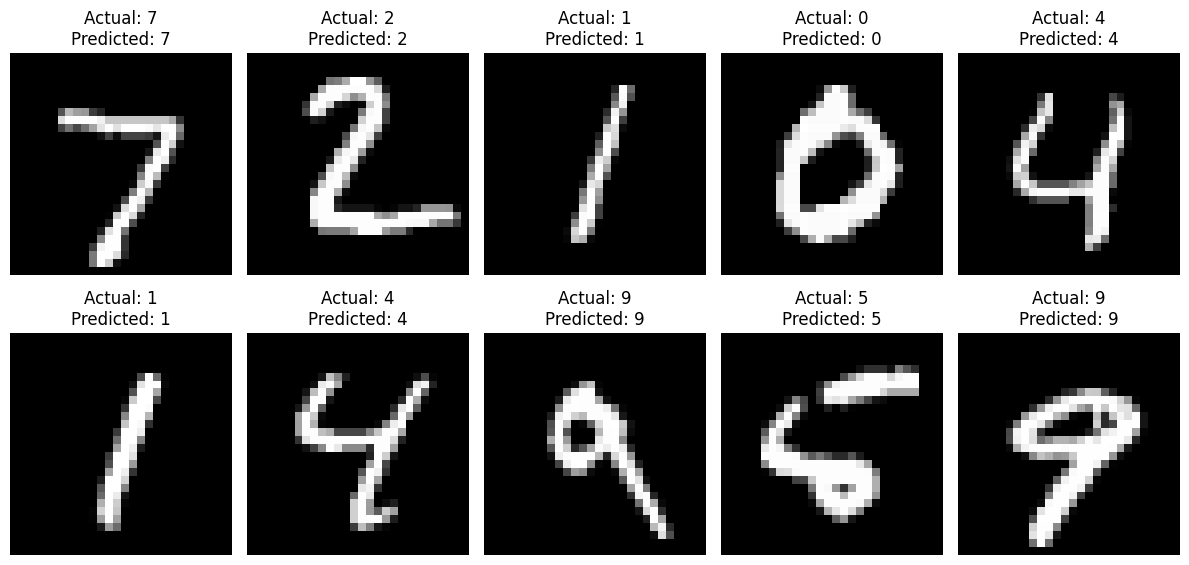

In [1]:
# Practical 6: Handwritten Digit Recognition using CNN
# Code by Parthiv Abhani

import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np

# Load MNIST Dataset
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.mnist.load_data()

# Normalize pixel values
X_train = X_train / 255.0
X_test = X_test / 255.0

# Reshape data for CNN: (samples, height, width, channels)
X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)

# Build CNN Model
model = tf.keras.Sequential([
    tf.keras.layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    tf.keras.layers.MaxPooling2D((2, 2)),

    tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D((2, 2)),

    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(10, activation='softmax')
])

# Compile Model
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Display Model Architecture
model.summary()

# Train Model
history = model.fit(
    X_train,
    y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.1
)

# Evaluate Model
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)

print("\nTest Accuracy:", round(test_accuracy * 100, 2), "%")
print("Test Loss:", round(test_loss, 4))

# Make Predictions
predictions = model.predict(X_test, verbose=0)
predicted_digits = np.argmax(predictions, axis=1)

# Display Prediction Results
plt.figure(figsize=(12, 6))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_test[i].reshape(28, 28), cmap='gray')
    plt.title(f"Actual: {y_test[i]}\nPredicted: {predicted_digits[i]}")
    plt.axis('off')

plt.tight_layout()
plt.show()